# Qwen3 Zero-Shot Sentiment Experiment

# Cell 1 — Checking Ollama is running and Qwen3 is available

In [1]:
import requests

try:
    r = requests.get("http://localhost:11434/api/tags", timeout=10)
    models = r.json().get("models", [])
    print("Available Ollama models:")
    for m in models:
        print(f"  {m['name']}  ({round(m.get('size',0)/1e9, 1)} GB)")
except Exception as e:
    print(f"Ollama not reachable: {e}")
    print("Start it with: ollama serve")

Available Ollama models:
  safe-agent-9b:latest  (6.6 GB)
  llama3:latest  (4.7 GB)
  mistral:latest  (4.4 GB)
  safe-agent-32b:latest  (20.2 GB)
  qwen3:32b  (20.2 GB)
  qwen3.5:9b  (6.6 GB)


# Cell 2 — Setting model name and loading data

In [2]:
import pandas as pd
import json
import re
import os
import requests
from tqdm import tqdm

QWEN3_MODEL = "qwen3.5:9b"   # e.g. "qwen3:8b", "qwen3:14b", "qwen3:1.7b", etc.

df = pd.read_csv("headlines_raw.csv")
headlines = df["headline"].tolist()

print(f"Model to use  : {QWEN3_MODEL}")
print(f"Total headlines: {len(headlines)}")
print(df["label"].value_counts())

Model to use  : qwen3.5:9b
Total headlines: 14308
label
neutral     8990
positive    3273
negative    2045
Name: count, dtype: int64


# Cell 3 — Qwen3-specific prompt and parser

In [3]:
def build_zeroshot_prompt(headline: str) -> str:
    return (
        "Analyze the financial sentiment of this news headline.\n"
        'Respond with ONLY a JSON object: {"positive": float, "negative": float, "neutral": float}\n'
        "All three values must sum to 1.0. No explanation, just the JSON.\n"
        f"Headline: {headline}"
    )


def strip_think_tags(text: str) -> str:
    return re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()


def parse_json_sentiment(text: str) -> dict:
    default = {"positive": 0.3334, "negative": 0.3333, "neutral": 0.3333}
    try:
        text = strip_think_tags(text)
        match = re.search(r'\{[^{}]+\}', text)
        if match:
            result = json.loads(match.group())
            if all(k in result for k in ['positive', 'negative', 'neutral']):
                total = sum(result.values())
                if total > 0:
                    result = {k: v / total for k, v in result.items()}
                return result
    except Exception:
        pass
    return default


def get_qwen3_sentiment(headline: str) -> dict:
    prompt = build_zeroshot_prompt(headline)
    try:
        r = requests.post(
            "http://localhost:11434/api/generate",
            json={
                "model": QWEN3_MODEL,
                "prompt": prompt,
                "stream": False,
                "think": False,          
                "options": {
                    "temperature": 0.1,
                    "num_predict": 512
                }
            },
            timeout=90
        )
        text = r.json().get("response", "")
        return parse_json_sentiment(text)
    except Exception:
        return {"positive": 0.3334, "negative": 0.3333, "neutral": 0.3333}


print("=== SANITY CHECK (3 headlines) ===")
for h in headlines[:3]:
    result = get_qwen3_sentiment(h)
    pred = max(result, key=result.get)
    print(f"  '{h[:70]}...'")
    print(f"   → {result}  pred: {pred}\n")

=== SANITY CHECK (3 headlines) ===
  'According to Gran , the company has no plans to move all production to...'
   → {'positive': 0.1, 'negative': 0.1, 'neutral': 0.8}  pred: neutral

  'Technopolis plans to develop in stages an area of no less than 100,000...'
   → {'positive': 0.4, 'negative': 0.1, 'neutral': 0.5}  pred: neutral

  'The international electronic industry company Elcoteq has laid off ten...'
   → {'positive': 0.1, 'negative': 0.7, 'neutral': 0.2}  pred: negative



# Cell 4 — Run Qwen3 zero-shot on all headlines

In [4]:
SAVE_PATH = "sentiment_qwen3.csv"

if os.path.exists(SAVE_PATH):
    done = pd.read_csv(SAVE_PATH)
    start_idx = len(done)
    results = done.to_dict("records")
    print(f"Resuming from index {start_idx} / {len(headlines)}")
else:
    results = []
    start_idx = 0
    print(f"Starting fresh. Total headlines: {len(headlines)}")

fallback_count = 0

for i, h in enumerate(tqdm(headlines[start_idx:], desc=f"Qwen3 ({QWEN3_MODEL})"),
                       start=start_idx):
    s = get_qwen3_sentiment(h)
    if abs(s["positive"] - 0.33) < 0.001:
        fallback_count += 1
    results.append({
        "qwen3_positive": s["positive"],
        "qwen3_negative": s["negative"],
        "qwen3_neutral":  s["neutral"]
    })
    if (i + 1) % 100 == 0:
        pd.DataFrame(results).to_csv(SAVE_PATH, index=False)

pd.DataFrame(results).to_csv(SAVE_PATH, index=False)
print(f"\nDone. Saved to {SAVE_PATH}")
print(f"Fallback (parse failures): {fallback_count} / {len(headlines)} "
      f"({100*fallback_count/len(headlines):.2f}%)")

Starting fresh. Total headlines: 14308


Qwen3 (qwen3.5:9b): 100%|███████████████████████████████████████████████████████| 14308/14308 [5:14:33<00:00,  1.32s/it]


Done. Saved to sentiment_qwen3.csv
Fallback (parse failures): 1456 / 14308 (10.18%)


# Cell 5 — Evaluate Qwen3

In [5]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

df_base = pd.read_csv("headlines_raw.csv")
df_q3   = pd.read_csv("sentiment_qwen3.csv")

df_eval = pd.concat([df_base.reset_index(drop=True),
                     df_q3.reset_index(drop=True)], axis=1)

def probs_to_label(row, prefix):
    return max(
        {"positive": row[f"{prefix}_positive"],
         "negative": row[f"{prefix}_negative"],
         "neutral":  row[f"{prefix}_neutral"]},
        key=lambda k: {"positive": row[f"{prefix}_positive"],
                       "negative": row[f"{prefix}_negative"],
                       "neutral":  row[f"{prefix}_neutral"]}[k]
    )

true  = df_eval["label"].tolist()
pred  = df_eval.apply(lambda r: probs_to_label(r, "qwen3"), axis=1).tolist()

acc  = accuracy_score(true, pred)
f1m  = f1_score(true, pred, average="macro",    labels=["positive","negative","neutral"])
f1w  = f1_score(true, pred, average="weighted", labels=["positive","negative","neutral"])

pb_mask = df_eval["source"] == "phrasebank"
tw_mask = df_eval["source"] == "twitter"
acc_pb = accuracy_score(df_eval.loc[pb_mask,"label"],
                        [p for p,m in zip(pred, pb_mask) if m])
acc_tw = accuracy_score(df_eval.loc[tw_mask,"label"],
                        [p for p,m in zip(pred, tw_mask) if m])

print(f"{'Metric':<20} {'Qwen3':>10}")
print("-" * 32)
print(f"{'Accuracy':<20} {acc:>10.4f}")
print(f"{'F1 Macro':<20} {f1m:>10.4f}")
print(f"{'F1 Weighted':<20} {f1w:>10.4f}")
print(f"{'Acc PhraseBank':<20} {acc_pb:>10.4f}")
print(f"{'Acc Twitter':<20} {acc_tw:>10.4f}")

print("\n=== Per-class report ===")
print(classification_report(true, pred, labels=["positive","negative","neutral"]))

df_eval["qwen3_pred"] = pred
df_eval.to_csv("sentiment_qwen3_eval.csv", index=False)

Metric                    Qwen3
--------------------------------
Accuracy                 0.6982
F1 Macro                 0.6928
F1 Weighted              0.7019
Acc PhraseBank           0.8101
Acc Twitter              0.6412

=== Per-class report ===
              precision    recall  f1-score   support

    positive       0.56      0.86      0.68      3273
    negative       0.54      0.93      0.69      2045
     neutral       0.92      0.58      0.71      8990

    accuracy                           0.70     14308
   macro avg       0.67      0.79      0.69     14308
weighted avg       0.78      0.70      0.70     14308



# Cell 6 — Neutral class bias check

In [6]:
neutral_df = df_eval[df_eval["label"] == "neutral"]
counts = neutral_df["qwen3_pred"].value_counts(normalize=True) * 100

print(f"Truly neutral headlines: {len(neutral_df)}\n")
print("Qwen3 prediction distribution on neutral headlines:")
print(f"  Pred Negative : {counts.get('negative', 0):.1f}%")
print(f"  Pred Neutral  : {counts.get('neutral',  0):.1f}%")
print(f"  Pred Positive : {counts.get('positive', 0):.1f}%")

neutral_f1 = f1_score(true, pred, average=None,
                      labels=["negative","neutral","positive"])[1]
print(f"\nNeutral class F1: {neutral_f1:.4f}")

Truly neutral headlines: 8990

Qwen3 prediction distribution on neutral headlines:
  Pred Negative : 17.0%
  Pred Neutral  : 58.4%
  Pred Positive : 24.6%

Neutral class F1: 0.7141


# Cell 7 — Comparison table

In [7]:
df_zshot = pd.read_csv("sentiment_all.csv")

existing = [
    {"Model": "FinBERT",    "Accuracy": 0.7712, "F1_macro": 0.7373,
     "F1_weighted": 0.7769, "Acc_PhraseBank": 0.8890, "Acc_Twitter": 0.7113},
    {"Model": "Mistral-7B", "Accuracy": 0.5347, "F1_macro": 0.5419,
     "F1_weighted": 0.5148, "Acc_PhraseBank": 0.6471, "Acc_Twitter": 0.4775},
    {"Model": "Llama3-8B",  "Accuracy": 0.3502, "F1_macro": 0.3768,
     "F1_weighted": 0.2003, "Acc_PhraseBank": 0.3932, "Acc_Twitter": 0.3283},
]

qwen3_row = {
    "Model": f"Qwen3 ({QWEN3_MODEL})",
    "Accuracy": acc, "F1_macro": f1m,
    "F1_weighted": f1w,
    "Acc_PhraseBank": acc_pb, "Acc_Twitter": acc_tw
}

df_final = pd.DataFrame(existing + [qwen3_row])

print("=== FINAL BENCHMARK TABLE (all 4 models) ===")
print(df_final.to_string(index=False))
df_final.to_csv("benchmark_final_with_qwen3.csv", index=False)

=== FINAL BENCHMARK TABLE (all 4 models) ===
             Model  Accuracy  F1_macro  F1_weighted  Acc_PhraseBank  Acc_Twitter
           FinBERT  0.771200  0.737300     0.776900        0.889000     0.711300
        Mistral-7B  0.534700  0.541900     0.514800        0.647100     0.477500
         Llama3-8B  0.350200  0.376800     0.200300        0.393200     0.328300
Qwen3 (qwen3.5:9b)  0.698211  0.692808     0.701886        0.810106     0.641207


# Cell 8 — McNemar test: Qwen3 vs all other models

In [8]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

df_full = pd.read_csv("sentiment_final.csv")  # from Research_paper.ipynb Cell 19
true_arr = np.array(df_full["label"].tolist())
qwen3_arr = np.array(pred)

def mcnemar_vs_qwen3(other_col):
    other = np.array(df_full[other_col].tolist())
    c_q = (qwen3_arr == true_arr)
    c_o = (other     == true_arr)
    n10 = ((c_q) & (~c_o)).sum()
    n01 = ((~c_q) & (c_o)).sum()
    result = mcnemar([[0, n10], [n01, 0]], exact=False, correction=True)
    return result.pvalue

comparisons = [
    ("Qwen3 vs FinBERT",   "finbert_pred"),
    ("Qwen3 vs Mistral-7B","mistral_pred"),
    ("Qwen3 vs Llama3-8B", "llama3_pred"),
]

print(f"{'Comparison':<30} {'p-value':<12} {'Significant?'}")
print("-" * 56)
for label, col in comparisons:
    try:
        p = mcnemar_vs_qwen3(col)
        sig = "YES (p<0.05)" if p < 0.05 else "NO"
        print(f"{label:<30} {p:<12.4f} {sig}")
    except Exception as e:
        print(f"{label:<30} ERROR: {e}")

Comparison                     p-value      Significant?
--------------------------------------------------------
Qwen3 vs FinBERT               0.0000       YES (p<0.05)
Qwen3 vs Mistral-7B            0.0000       YES (p<0.05)
Qwen3 vs Llama3-8B             0.0000       YES (p<0.05)


# Cell 9 — Bar chart: all 4 models 

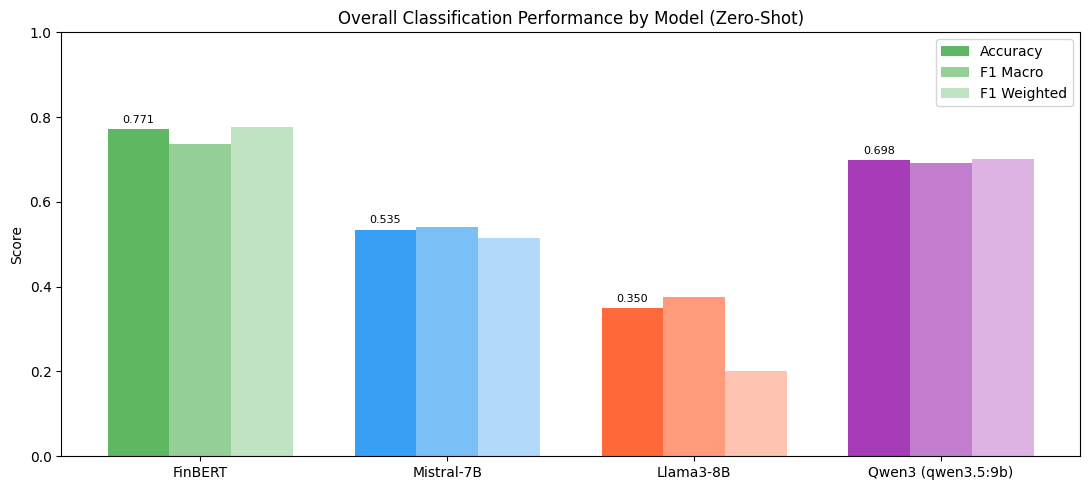

Figure saved.


In [9]:
import matplotlib.pyplot as plt
import numpy as np

df_res = pd.read_csv("benchmark_final_with_qwen3.csv")

models  = df_res["Model"].tolist()
acc     = df_res["Accuracy"].tolist()
f1m     = df_res["F1_macro"].tolist()
f1w     = df_res["F1_weighted"].tolist()

x  = np.arange(len(models))
w  = 0.25
colors = ["#4CAF50", "#2196F3", "#FF5722", "#9C27B0"]

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - w, acc, w, label="Accuracy",    color=[c for c in colors], alpha=0.9)
b2 = ax.bar(x,     f1m, w, label="F1 Macro",    color=[c for c in colors], alpha=0.6)
b3 = ax.bar(x + w, f1w, w, label="F1 Weighted", color=[c for c in colors], alpha=0.35)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title("Overall Classification Performance by Model (Zero-Shot)", fontsize=12)
ax.legend(fontsize=10)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("fig_all_models_comparison.pdf", dpi=300, bbox_inches='tight')
plt.savefig("fig_all_models_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [1]:
from sklearn.metrics import f1_score
import pandas as pd

df = pd.read_csv("sentiment_final.csv")
true = df["label"]

for model, col in [("FinBERT","finbert_pred"),
                   ("Mistral","mistral_pred"),
                   ("Llama3","llama3_pred")]:
    scores = f1_score(true, df[col], average=None,
                      labels=["negative","neutral","positive"])
    print(f"{model}: neg={scores[0]:.4f}, neu={scores[1]:.4f}, pos={scores[2]:.4f}")

FinBERT: neg=0.6806, neu=0.8242, pos=0.7072
Mistral: neg=0.5336, neu=0.4723, pos=0.6197
Llama3: neg=0.6819, neu=0.0007, pos=0.4479
